## 1) Descripción del problema
*Contexto:* Consiste en un sistema de entrega de medicamentos de una farmacia hospitalaria, donde el objetivo es administrar el flujo de pacientes siguiendo unas pautas de prioridad. El sistema deber ser capaz de organizar a los pacientes en dos categorias distintas, asegurando que la atención se asigne primero a quienes tienen una condición medica critica, sin perder el orden de llegada dentro de cada grupo. Pautas: 
- 1. Los pacientes normales se atienden en orden de llegada. 
- 2. Los pacientes críticos tienen prioridad sobre los normales.
- 3. Entre pacientes críticos también se respeta el orden de llegada. 
- 4. Solo puede haber un paciente en atención.
- 5. Cuando se atiende a un paciente, este se elimina del sistema.


## 2) Requerimientos
Lista requerimientos **funcionales** y **no funcionales**.
### *Requerimientos funcionales*
**RF01** – Permitir registrar pacientes normales.

**RF02** – Permitir registrar pacientes críticos.

**RF03** – Mantener el orden de llegada de los pacientes mediante una estructura tipo cola.

**RF04** – Dar prioridad a los pacientes críticos.

**RF05** – Permitir atender pacientes.

**RF06** – Mostrar el paciente que está siendo atendido.

**RF07** – Mostrar un mensaje cuando no hay pacientes.
### *Requerimientos no funcionales*
- El sistema debe ser desarrollado en Python.
- No se deben utilizar librerías externas.
- La estructura de cola debe implementarse manualmente.
- El programa debe ejecutarse en consola.
- El código debe ser claro y modular.
- El sistema debe ser capaz de gestionar un aumento repentino en el volumen de pacientes sin degradar la lógica de prioridad establecida.




## 3) Historias de usuario
### *H01-Registro de usuarios y clasificación.*
- *Descripción:* El sistema permite el ingreso de pacientes o usuarios mediante un comando que especifica su nivel de prioridad (Crítico/Prioritario o Normal/General) seguido de su nombre.
- *Caso exitoso:* Se ingresa un comando válido (ej. C Juan o N Marta). El sistema identifica el tipo de prioridad y almacena el nombre en la cola correspondiente, confirmando el registro de forma exitosa.
- *Caso no exitoso:* El usuario ingresa una cadena vacía o un comando con un formato que el sistema no reconoce. El sistema no realiza ninguna acción y queda a la espera de un dato válido.
- *Entrada:* [Clasificación, Nombre]
- *Salida:* No hay salida, el sistema procesa los datos.
### *H02-Atención por clasificación de prioridad*
- *Descripción:* El sistema procesa la atención de los usuarios en ventanilla cada vez que se solicita la acción de "atender". Debe garantizar que ningún usuario de tipo Normal sea atendido mientras exista alguien en la fila de prioritarios.
- *Caso exitoso:* Existen pacientes en espera. Al solicitar atención, el sistema extrae al primer usuario de la cola de prioritarios. Si esta está vacía, extrae al primero de la cola de normales.
- *Caso no exitoso:* El usuario solicita atención cuando ambas colas están vacías. El sistema identifica la ausencia de datos y notifica que no hay pendientes.
- *Entrada:* Se pide atención.
- *Salida:* Se atiendde al usuario que solicito atención, deacuerdo a la prioridad y si hay mas usuarios. 
### *H03-Manejar sistema sin pacientes*
- *Descripción:* El sistema debe informar cuando se intenta atender pacientes pero no hay pacientes en ninguna cola.
- *Caso exitoso:* El usuario intenta atender pacientes pero no hay pacientes por atender, por lo que se muestra un mensaje "no hay pacientes".
- *Caso no exitoso:* El usuario solicita atención pero el sistema encuentra pacientes en alguna de las colas, por lo que se procede a atender al paciente correspondiente según la prioridad.
- *Entrada:* Se pide atención "A".
- *Salida:* No hay pacientes. 



## 4) Diagramas de flujo
Este diagrama de flujo muestra el proceso en el cual se debe desarrollar el codigo, Teniendo un solo for y varios if donde se determinan el tipo de paciente que es (prioritario, normal o si es para dar salida).



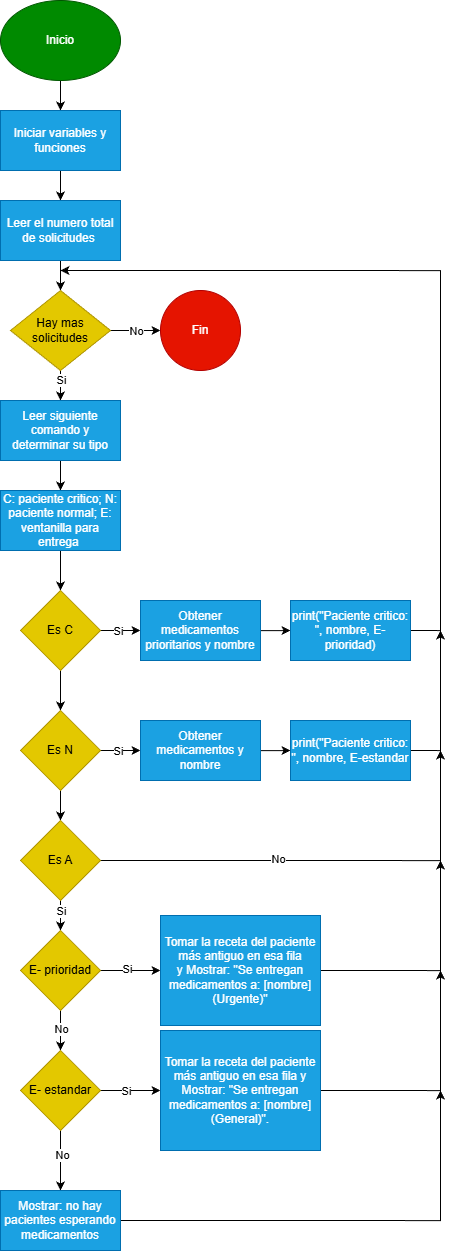

In [ ]:
from IPython.display import Image
Image("flujo.png")

## 5) Diagramas de secuencia

En este diagrama de secuencia representamos los función básica del código, donde el usuario identifica al paciente y lo categoriza como paciente critico o normal, donde estos nombres y según la categorización lo archivamos en una lista, vamos a tener como prioridad a los pacientes críticos, y cuando termina de atender a los pacientes críticos pasa a los pacientes normales, eliminando a cada paciente atendido. Por ultimo, imprimir a los pacientes según el orden de llamada.

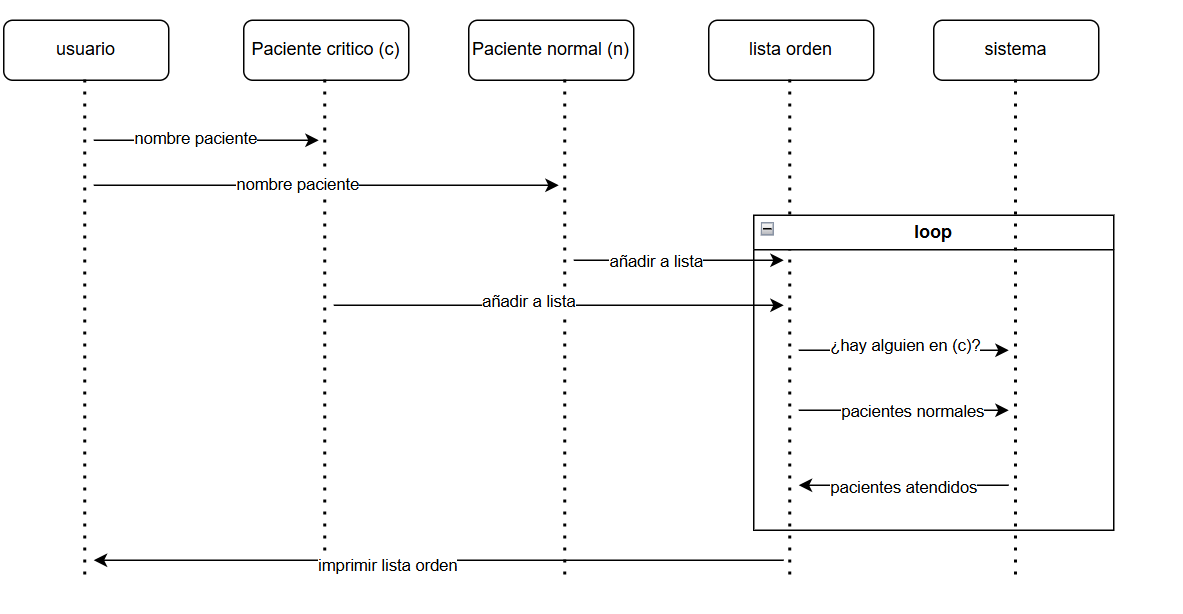

In [2]:
from IPython.display import Image
Image("image.png")

## 6) Diagramas de casos de uso
En este diagrama se muestra lo que ve el usuario y tiene que hacer y lo que tiene que hacer el sistema. Primero el usuario ingresa su nombre y su prioridad, luego el sistema toma los datos ingresados y determina deacuerdo a la prioridad el orden de atencion. Cuando el usuario ve el orden de los pacientes y a medida que los va atendiendo el sistema elimina a estos. 


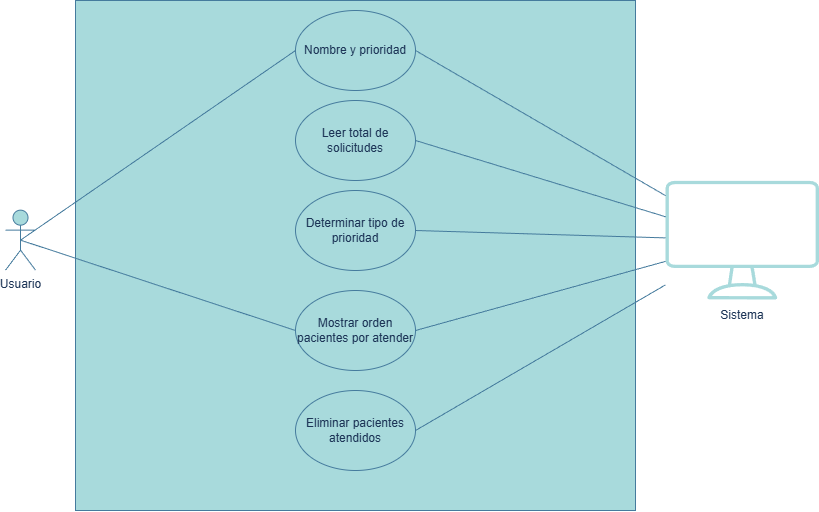

In [3]:
from IPython.display import Image
Image("Casos.png")

## 7) Análisis de complejidad

El programa al solo tener un solo for la funcion tendria una complejidad de $O(n)$ los if no interfieren en la complejidad. Sin embargo, las definiciones para hacer la funcion de desencolar utiliza un .pop() y esto tiene una complejidad de $O(n)$ por lo que en conclusion todo el programa tiene una complejidad de $O(n^2)$

### *Mejor caso*
- El mejor caso de este programa es $O(n)$ ocurre cuando ll programa recorre la entrada una sola vez para organizar quién es "Crítico" y quién es "Normal". Al ser un solo recorrido sobre la cantidad total de pacientes $n$, la eficiencia es puramente lineal. No hay búsquedas complejas ni otros ordenamientos que sean complejos, solo una distribución directa de elementos en las estructuras de espera que planteamos.
- Donde su grafica es:


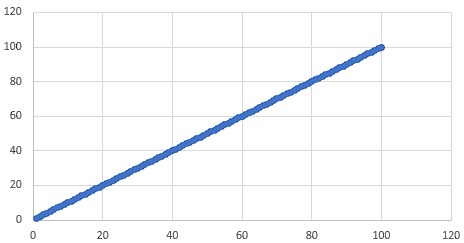

In [2]:
from IPython.display import Image
Image("Grafica_mc.png")

### *Peor caso*
- El peor caso de este programa es $O(n^2)$ que ocurre cuando tenemos $n$ pacientes y por cada uno de ellos el sistema realiza una operación que escala con el tamaño de la lista, termina realizando $n$ operaciones por cada uno de los $n$ pacientes, resultando en la peor complejidad.
- Donde su grafica es: 

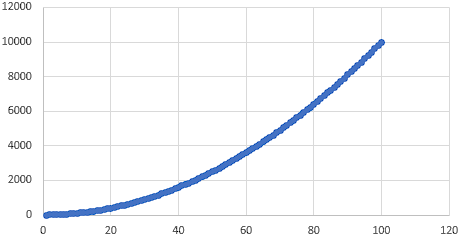

In [3]:
from IPython.display import Image
Image("Grafica_pc.png")

## 8) Tests

*Test 1:*

---

**Entrada**

```text
4
N JUAN
C MARIA
A
A
```

---

**Salida esperada**

```text
Paciente N nuevo: JUAN
Paciente C nuevo: MARIA
Se atiende a MARIA
Se atiende a JUAN
```

*Test 2:*

---

**Entrada**

```text
4
A
A
```

---

**Salida esperada**

```text
no hay pacientes
no hay pacientes
```

## 9) Código funcional



In [9]:
def pacientes(entrada):

    # PROCESAR ENTRADA

    lineas = entrada.strip().split("\n")

    n = int(lineas[0])
    acciones = lineas[1:]

    # COLAS

    cola_normales = []
    cola_criticos = []

    salida = []

    # SISTEMA DE PACIENTES

    for accion in acciones:

        datos = accion.split()

        # Paciente normal
        if datos[0] == "N":

            nombre = datos[1]
            cola_normales.append(nombre)

            salida.append(f"Paciente N nuevo: {nombre}")

        # Paciente crítico
        elif datos[0] == "C":

            nombre = datos[1]
            cola_criticos.append(nombre)

            salida.append(f"Paciente C nuevo: {nombre}")

        # Atender paciente
        elif datos[0] == "A":

            # Primero se atienden críticos
            if len(cola_criticos) > 0:

                paciente = cola_criticos.pop(0)
                salida.append(f"Se atiende a {paciente}")

            # Si no hay críticos, se atienden normales
            elif len(cola_normales) > 0:

                paciente = cola_normales.pop(0)
                salida.append(f"Se atiende a {paciente}")

            # Si no hay pacientes
            else:

                salida.append("no hay pacientes")
        else:
            return ["Error: entrada invalida"]

    return salida

# ENTRADA SIMULADA
entrada = """
8
N JUAN
C MARIA
N DIANA
A
C DANIELA
A
A
A
"""

resultado = pacientes(entrada)

# Imprimir resultados
for r in resultado:
    print(r)

Paciente N nuevo: JUAN
Paciente C nuevo: MARIA
Paciente N nuevo: DIANA
Se atiende a MARIA
Paciente C nuevo: DANIELA
Se atiende a DANIELA
Se atiende a JUAN
Se atiende a DIANA


## 10) Tests aplicados



In [10]:
#Test 1
entrada1 = """
4
N JUAN
C MARIA
A
A
"""

resultado1 = pacientes(entrada1)

print("Test 1\n")

for r in resultado1:
    print(r)

#Test 2
entrada2 = """
2
A
A
"""

resultado2 = pacientes(entrada2)

print("\nTest 2\n")

for r in resultado2:
    print(r)

#Test 3
entrada3 = """
8
N IVAN
C JUAN
A
N MARIA
C DIANA
A
A
A
"""

resultado3 = pacientes(entrada3)

print("\nTest 3\n")

for r in resultado3:
    print(r)

#Test 4
entrada4 = """
8
N IVAN
F JUAN
A
A
"""

resultado4 = pacientes(entrada4)

print("\nTest 4\n")

for r in resultado4:
    print(r)



Test 1

Paciente N nuevo: JUAN
Paciente C nuevo: MARIA
Se atiende a MARIA
Se atiende a JUAN

Test 2

no hay pacientes
no hay pacientes

Test 3

Paciente N nuevo: IVAN
Paciente C nuevo: JUAN
Se atiende a JUAN
Paciente N nuevo: MARIA
Paciente C nuevo: DIANA
Se atiende a DIANA
Se atiende a IVAN
Se atiende a MARIA

Test 4

Error: entrada invalida
